In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df=pd.read_csv('/content/mymoviedb (1).csv', engine='python', on_bad_lines='skip')

In [6]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


In [8]:
df.isnull().sum()

,0
Release_Date,0
Title,9
Overview,9
Popularity,10
Vote_Count,10
Vote_Average,10
Original_Language,10
Genre,11
Poster_Url,11


In [9]:
(df == "").sum()

,0
Release_Date,0
Title,0
Overview,0
Popularity,0
Vote_Count,0
Vote_Average,0
Original_Language,0
Genre,0
Poster_Url,0


In [10]:
(df == " ").sum()

,0
Release_Date,0
Title,0
Overview,0
Popularity,0
Vote_Count,0
Vote_Average,0
Original_Language,0
Genre,0
Poster_Url,0


In [11]:
df['Genre']

,Genre
0,"Action, Adventure, Science Fiction"
1,"Crime, Mystery, Thriller"
2,Thriller
3,"Animation, Comedy, Family, Fantasy"
4,"Action, Adventure, Thriller, War"
...,...
9832,"Drama, Crime"
9833,Horror
9834,"Mystery, Thriller, Horror"
9835,"Music, Drama, History"


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.describe()

,Popularity
count,9827.000000
mean,40.320570
std,108.874308
min,7.100000
25%,16.127500
50%,21.191000
75%,35.174500
max,5083.954000


* Exploration Summary  

* we have a dataframe consisting of 9837 and 9 columns.  
* in our dataset there are some missing values in some columns
* Release_date column is needs to be casted into datetime and vote count and vote average casted into int and float respectively.  
* Overview,Original_language and Poster-Url wouldn't be so useful during analysis, so we'll drop then.  
* there is noticable outlier in popularity column .
* Vote_average better be categorised for proper analysis.
* Genre column has comma seperated values and white spaces that needs that needs to be handled and casted into category.

In [14]:
df = df.dropna() #removes duplicates

In [15]:
df.isnull().sum()

,0
Release_Date,0
Title,0
Overview,0
Popularity,0
Vote_Count,0
Vote_Average,0
Original_Language,0
Genre,0
Poster_Url,0


In [16]:
len(df) #total row counts

9826

In [17]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [18]:
df['Release_Date']=pd.to_datetime(df['Release_Date'])
print(df['Release_Date'].dtype)

datetime64[ns]


In [19]:
df['Release_Date']=df['Release_Date'].dt.year
df['Release_Date'].dtypes

dtype('int32')

In [20]:
df.head(1)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...


In [21]:
df['Vote_Count']=pd.to_numeric(df['Vote_Count'], errors='coerce').astype('Int64')
print(df['Vote_Count'].dtype)
df['Vote_Average']=pd.to_numeric(df['Vote_Average'], errors='coerce').astype(float)
print(df['Vote_Average'].dtype)

Int64
float64


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9826 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9826 non-null   int32  
 1   Title              9826 non-null   object 
 2   Overview           9826 non-null   object 
 3   Popularity         9826 non-null   float64
 4   Vote_Count         9826 non-null   Int64  
 5   Vote_Average       9826 non-null   float64
 6   Original_Language  9826 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: Int64(1), float64(2), int32(1), object(5)
memory usage: 996.9+ KB


In [23]:
#dropping the columns
col=['Overview','Original_Language','Poster_Url']
df.drop(col,axis=1,inplace=True)

**Categorizing Vote_Average column**  
WE would cut the Vote_Average values and make 4 categories:popular,average,below_avg,not_popular to describe it more using categorize_col() function provided above.

In [24]:
def categorize_col(df,col,label):
  # Ensure the column is numeric before calculating descriptive statistics
  numeric_col = pd.to_numeric(df[col], errors='coerce')

  # Handle cases where conversion results in all NaNs (e.g., if column was already purely string labels)
  if numeric_col.isnull().all() and not df[col].isnull().all():
      raise ValueError(f"Column '{col}' could not be converted to numeric for categorization. It might already contain non-numeric categorical labels without underlying numeric values.")

  edges=[
      numeric_col.describe()['min'],
      numeric_col.describe()['25%'],
      numeric_col.describe()['50%'],
      numeric_col.describe()['75%'],
      numeric_col.describe()['max']
  ]
  df[col]=pd.cut(numeric_col,bins=edges,labels=label,include_lowest=True,duplicates='drop')
  return df

In [25]:
labels=["not_popular","below_avg","average","popular"]
df=categorize_col(df,"Vote_Average",labels)
df['Vote_Average'].unique()

['popular', 'below_avg', 'average', 'not_popular']
Categories (4, object): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [26]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [27]:
df["Vote_Average"].value_counts()

,count
Vote_Average,
not_popular,2567
popular,2450
average,2411
below_avg,2398


In [28]:
df.dropna(inplace=True)
df.isna().sum()

,0
Release_Date,0
Title,0
Popularity,0
Vote_Count,0
Vote_Average,0
Genre,0


**we will split genre into a list and then explode our dataframe to have only one genre per row for each movie::**

In [29]:
df['Genre'] = df['Genre'].str.split(', ')
df = df.explode('Genre').reset_index(drop=True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


**casting column into category**

In [30]:
df['Genre']=df['Genre'].astype('category')
df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25792 entries, 0 to 25791
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25792 non-null  int32   
 1   Title         25792 non-null  object  
 2   Popularity    25792 non-null  float64 
 3   Vote_Count    25792 non-null  Int64   
 4   Vote_Average  25792 non-null  category
 5   Genre         25792 non-null  category
dtypes: Int64(1), category(2), float64(1), int32(1), object(1)
memory usage: 781.8+ KB


In [32]:
df.nunique()

,0
Release_Date,102
Title,9512
Popularity,8159
Vote_Count,3266
Vote_Average,4
Genre,19


In [33]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


**Data visualisation**

In [34]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

**what is the most frequent genre of movies released on neflix ?**

In [35]:
df['Genre'].describe()

,Genre
count,25792
unique,19
top,Drama
freq,3744


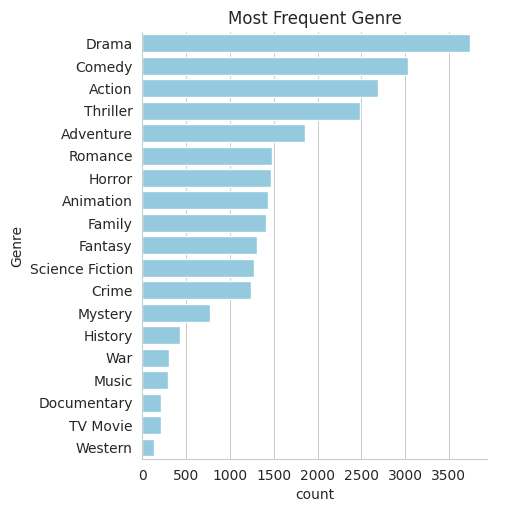

In [36]:
sns.catplot(y='Genre',kind='count',data=df,
            order=df['Genre'].value_counts().index,color='skyblue')
plt.title('Most Frequent Genre')
plt.show()

**which has highest votes in vote avg column?**

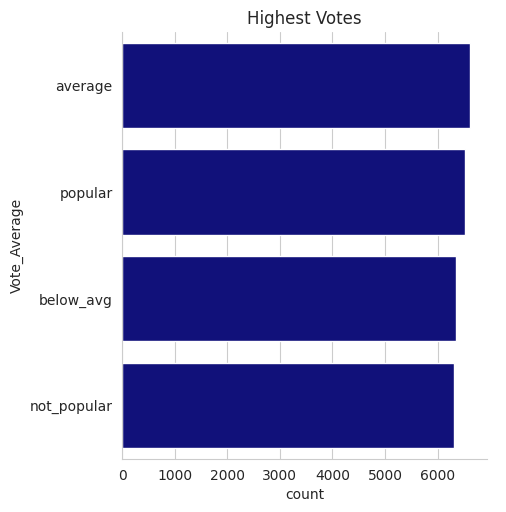

In [37]:
sns.catplot(y='Vote_Average',data=df,kind='count',
            order=df['Vote_Average'].value_counts().index,color='darkblue')
plt.title('Highest Votes')
plt.show()

**what movie got the highest popularity? what's its genre?**

In [38]:
df[df['Popularity']==df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction


**What movie got the lowest popularity? what's its genre?**

In [39]:
df[df['Popularity']==df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25786,2021,The United States vs. Billie Holiday,13.354,152,average,Music
25787,2021,The United States vs. Billie Holiday,13.354,152,average,Drama
25788,2021,The United States vs. Billie Holiday,13.354,152,average,History
25789,1984,Threads,13.354,186,popular,War
25790,1984,Threads,13.354,186,popular,Drama
25791,1984,Threads,13.354,186,popular,Science Fiction


**which year has the most filmed movies?**

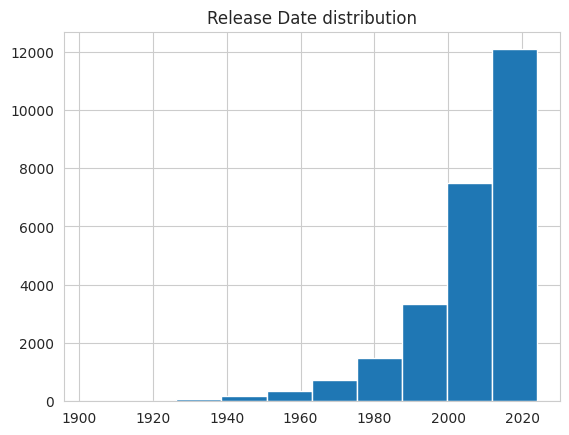

In [40]:
df['Release_Date'].hist()
plt.title("Release Date distribution")
plt.show()

**Most Frequent Genre**: 'Drama' is the most frequent genre among the movies in the dataset.

**Highest Votes (Vote_Average)**: The 'not_popular' category has the highest count in the Vote_Average column, followed closely by 'popular', 'average', and 'below_avg'. This indicates that while there are many movies that are not popular, there is also a significant number that are considered popular.

**Highest Popularity Movie**: The movie with the highest popularity is 'Spider-Man: No Way Home', which belongs to the genres 'Action', 'Adventure', and 'Science Fiction'.

  **Lowest Popularity Movie**: The movie with the lowest popularity is 'The United States vs. Billie Holiday' (genres: Music, Drama, History) and 'Threads' (genres: War, Drama, Science Fiction). These movies share the same minimum popularity value  
  
  **Release Date Distribution**: The histogram of 'Release_Date' (which is the year of release) would show the distribution of movies across different years, indicating which years had the most film releases in this dataset. (The plot itself was shown, but a textual summary would describe the visible trends, e.g., a peak in recent years or a specific decade).
